<a href="https://colab.research.google.com/github/elKiruvi/SARIMA-carros-usados-antioquia/blob/main/SARIMA_carros_usados_antioquia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo SARIMA para la búsqueda de carros usados en Antioquia

## 1.Introducción al Análisis de Series de Tiempo

Este estudio analiza el interés del consumidor en el mercado de vehículos de segunda mano en Antioquia, utilizando datos mensuales de Google Trends para la búsqueda de "carros usados" desde 2006 como un indicador adelantado de la demanda en el departamento. Dado que este mercado es un sensible barómetro de la actividad económica regional, la motivación principal es aplicar un modelo econométrico SARIMA para entender los patrones temporales, como tendencias y estacionalidades, que rigen el comportamiento del consumidor. El objetivo final es desarrollar un modelo predictivo que no solo explique la dinámica histórica, sino que también permita pronosticar futuras fluctuaciones en el interés, transformando la huella digital del público en inteligencia de mercado accionable para actores clave del sector.

## 2.Exploración de la base de datos

###2.1
¿Qué tipo de información se puede obtener al visualizar una serie de tiempo? Menciona al menos tres aspectos que se pueden identificar mediante la visualización.

- Tendencia: La dirección general o movimiento a largo plazo de la serie. Puede ser ascendente (creciente), descendente (decreciente) o estacionaria (sin una dirección clara a lo largo del tiempo). En este trabajo es crucial porque se necesita que la serie sea estacionaria.
- Varianza: Indentifica la amplitud de las fluctuaciones. Si es constante es homocedástica o si cambia con el tiempo es heterocedástica. También permite identificar valores atípicos y cambios estructurales.
- Estacionalidad: Patrones que se repiten a intervalos fijos y predecibles de tiempo. La visualización de estos patrones recurrentes justifica directamente el uso del componente estacional en el modelo.
- Variación irregular: Corresponde a las fluctuaciones aleatorias y no sistemáticas que permanecen en la serie temporal una vez descontados los efectos de la tendencia, el ciclo y la estacionalidad.

###2.2
Identifica las variables disponibles y la naturaleza de los datos de series de tiempo.

Variables:

* Mes (fue convertida a Fecha): date; desde enero de 2006 hasta octubre de 2025.
* Carros usados: (Antioquia): int; no tiene decimales porque las búsquedas se cuentan en números enteros. Conteo discreto.

In [ ]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
sns.set()

In [ ]:
# Leemos la base de datos que está en Csv

data = pd.read_csv('datos_Final.csv')

In [ ]:
# Miramos los encabezados, indices y los 5 primeros registros

data.head(5)

,Mes,carros usados: (Antioquia)
0,2006-01,78
1,2006-02,53
2,2006-03,48
3,2006-04,71
4,2006-05,41


In [ ]:
# Cambiamos el nombre a las columnas para que sea más comprensible y más facil
# de manipular

data.columns=['Fecha','Busquedas']

In [ ]:
# Convertimos la fecha a tipo de dato datetime y la seteamos como índice

data['Fecha']= pd.to_datetime(data['Fecha'])
data.set_index('Fecha',inplace=True)

In [ ]:
# Visualizamos la base de datos preparada

data

,Busquedas
Fecha,
2006-01-01,78
2006-02-01,53
2006-03-01,48
2006-04-01,71
2006-05-01,41
...,...
2025-06-01,15
2025-07-01,14
2025-08-01,16


###2.3
 Realiza un análisis exploratorio de los datos consignados en esta base de datos. ¿Qué tipo de análisis estadístico se puede realizar en una serie de tiempo para comprender mejor sus características? Utiliza una librería Python para trazar la serie de tiempo de la variable seleccionada, identificando tendencias, estacionalidad y otros patrones visuales.

* Los análisis estadísticos que se pueden realizar en una serie de tiempo son medidas como la media, la mediana, la desviación estándar y la varianza, que identifican las tendencias centrales y la dispersión de los datos. También, mediante gráficos de línea y boxplots, se pueden visualizar patrones, picos o caídas inusuales, así como la presencia de valores atípicos.

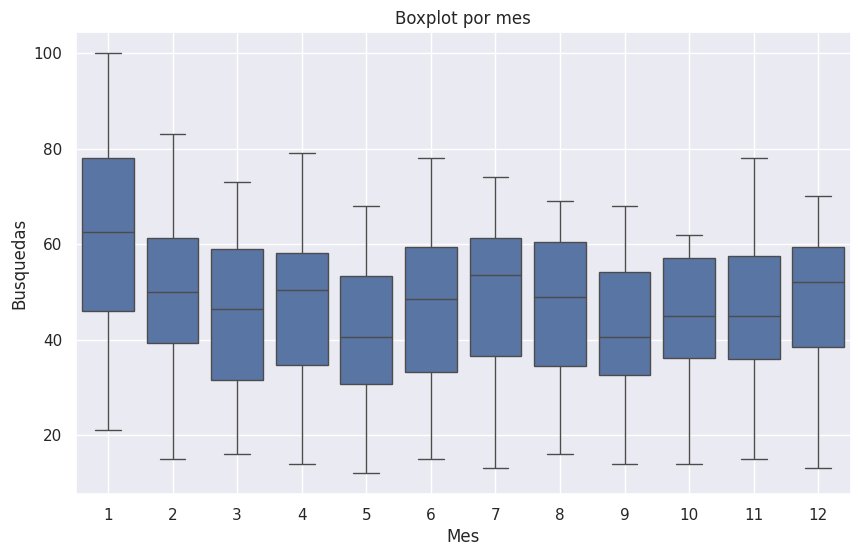

In [ ]:
# Boxplot por mes para detectar estacionalidad

plt.figure(figsize=(10,6))
sns.boxplot(x=data.index.month, y=data['Busquedas'], data=data)
plt.xlabel('Mes')
plt.ylabel('Busquedas')
plt.title("Boxplot por mes")
plt.grid(True)
plt.show()

El Boxplot muestra un claro patrón estacional en el volumen de búsquedas, con un pico muy pronunciado en enero (mes 1), que es el mes de mayor actividad y variabilidad. Tras este pico, el interés disminuye significativamente hasta alcanzar su punto más bajo en el mes 5, para luego recuperarse y mantenerse en un nivel moderado y estable durante toda la segunda mitad del año.

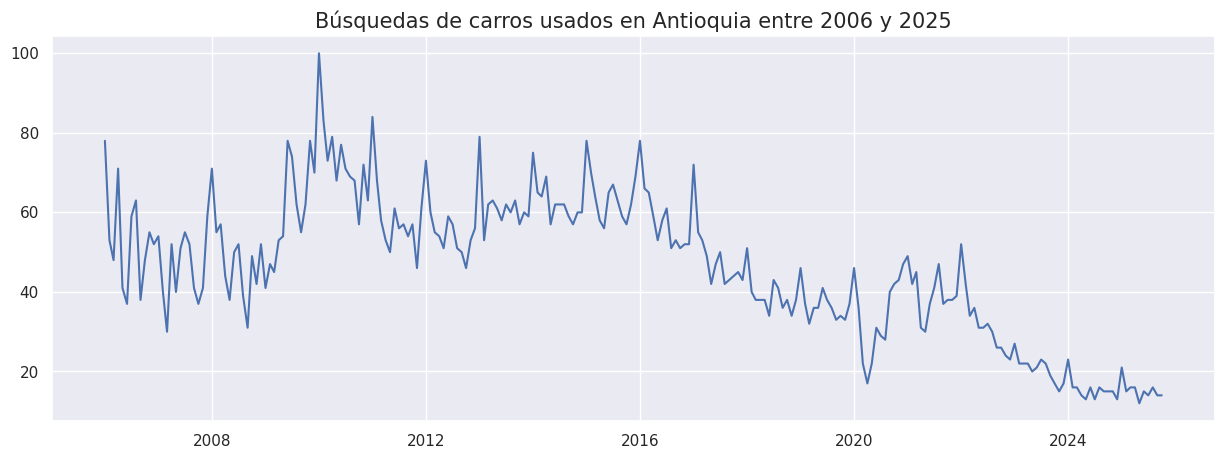

In [ ]:
# Visualizamos la serie de datos original

plt.figure(figsize=(15,5))
plt.title("Búsquedas de carros usados en Antioquia entre 2006 y 2025", fontsize = 15)
plt.plot(data)
plt.show()

Análisis de la serie de tiempo

1. Tendencia

La serie no posee visualemente una tendencia única y constante, lo que la hace no estacionaria en la media. Se observan tres fases distintas: un crecimiento inicial hasta 2010, un largo período de estabilidad a un nivel alto hasta 2017, y una clara tendencia a la baja desde entonces, que se acentúa a partir de 2021. Para que el modelo SARIMA pueda funcionar, esta tendencia debe ser eliminada, lo que requerirá aplicar al menos una diferenciación regular (d=1).

2. Estacionalidad

La gráfica muestra un patrón que se repite de forma regular, con picos y valles que ocurren en momentos similares cada año. Esta ciclicidad sugiere un fuerte componente estacional anual, lo cual es la justificación principal para usar un modelo SARIMA.

3. Varianza

La varianza de la serie no es constante a lo largo del tiempo; las fluctuaciones son mucho más amplias cuando el nivel de búsquedas es alto y se reducen significativamente a medida que el nivel general de la serie disminuye.

4. Quiebres Estructurales

La serie presenta cambios abruptos que no son parte de la tendencia o estacionalidad regular, destacando una caída muy pronunciada en 2020 que puede deberse a la pandemia de COVID-19. Este tipo de shock externo puede ser difícil de capturar para el modelo SARIMA.

In [ ]:
# Hacemos un describe para obtener las estadísticas descriptivas de la variable
# "Busquedas"

data.describe()

,Busquedas
count,238.000000
mean,46.394958
std,17.880154
min,12.000000
25%,36.000000
50%,48.500000
75%,59.000000
max,100.000000


###2.4
Calcula estadísticas descriptivas básicas de la serie de tiempo, como la media, la mediana, la desviación estándar, etc ¿Qué puedes concluir acerca de estos resultados?

* Desviacion estandar= 17.88, en promedio los valores de carros usados en Antioquia se desvian +- 18 unidades del valor medio

* Media= El valor promedio de busquedas mensuales es de 46.39

* Mediana=48.50

El interés mensual por carros usados en Antioquia se centra en un nivel moderado y estable, con una media de 46.39 y una mediana de 48.50; la proximidad entre estos dos valores sugiere una distribución de los datos relativamente simétrica, sin la influencia de valores atípicos extremos. No obstante, esta aparente estabilidad central contrasta con una notable volatilidad, evidenciada por una desviación estándar de 17.88, que indica que los valores mensuales fluctúan significativamente alrededor del promedio.





##3.Preparación de los datos

Ya anteriormente se hizo el cambio de nombres de columnas, la conversión del formato de fecha y se puso como índice para facilitar el trabajo.

In [ ]:
# Verificamos la estacionariedad

!pip install statsmodels

from statsmodels.tsa.stattools import adfuller # Importamos el test de Dickey-Fuller

In [ ]:
#H0: No es estacionaria
#H1: Es estacionaria

def adfuller_test(busquedas):
    result = adfuller(busquedas)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print('El valor de p es menor a 0.05, lo que significa que podemos rechazar la hipótesis nula H0. Podemos concluir que los datos no tienen raíz unitaria y son estacionarios.')
    else:
        print('Evidencia débil contra la hipótesis nula, lo cual significa que la serie de tiempo tiene una raíz unitaria que indica que no es estacionaria.')

In [ ]:
# Aplicamos la función para verificar la estacionariedad de la serie

adfuller_test(data["Busquedas"])

ADF Test Statistic : -0.7596055173964994
p-value : 0.8307007166481759
#Lags Used : 13
Number of Observations Used : 224
Evidencia débil contra la hipótesis nula, lo cual significa que la serie de tiempo tiene una raíz unitaria que indica que no es estacionaria.


Los resultados de la prueba Dickey-Fuller confirman de manera estadística lo que ya habíamos intuido visualmente en la gráfica. Con un p-valor de 0.83, que es significativamente mayor al umbral común de 0.05, no podemos rechazar la hipótesis nula. Esto significa que la serie de tiempo tiene una raíz unitaria y, por lo tanto, es no estacionaria.

### Diferenciación

#### Primera diferencia

In [ ]:
# Hacemos un shift de 1 para la primera diferencia

data["Busquedas"],data["Busquedas"].shift(1)

(Fecha
 2006-01-01    78
 2006-02-01    53
 2006-03-01    48
 2006-04-01    71
 2006-05-01    41
               ..
 2025-06-01    15
 2025-07-01    14
 2025-08-01    16
 2025-09-01    14
 2025-10-01    14
 Name: Busquedas, Length: 238, dtype: int64,
 Fecha
 2006-01-01     NaN
 2006-02-01    78.0
 2006-03-01    53.0
 2006-04-01    48.0
 2006-05-01    71.0
               ... 
 2025-06-01    12.0
 2025-07-01    15.0
 2025-08-01    14.0
 2025-09-01    16.0
 2025-10-01    14.0
 Name: Busquedas, Length: 238, dtype: float64)

In [ ]:
data["d1_Busquedas"] = data["Busquedas"] - data["Busquedas"].shift(1)

In [ ]:
data["d1_Busquedas"].head() # Observamos que el primer valor es NaN

,d1_Busquedas
Fecha,
2006-01-01,NaN
2006-02-01,-25.0
2006-03-01,-5.0
2006-04-01,23.0
2006-05-01,-30.0


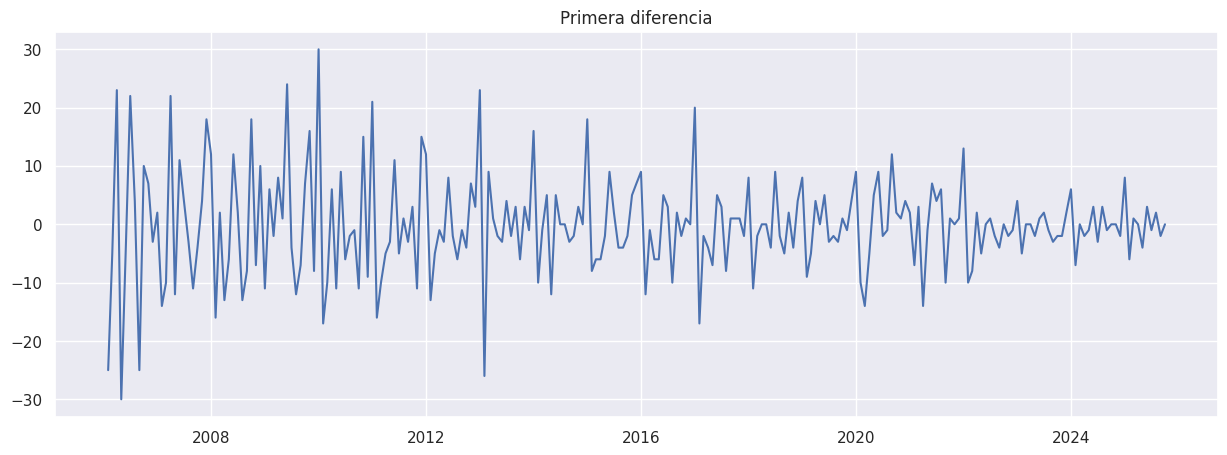

In [ ]:
#Graficamos la primera diferencia

plt.figure(figsize=(15,5))
plt.title("Primera diferencia")
plt.plot(data["d1_Busquedas"])
plt.show()

1. Estacionariedad

La transformación ha sido un éxito en cuanto a la tendencia. La serie ahora oscila consistentemente alrededor de un valor medio de cero. Ya no se aprecian las fases de crecimiento, estabilidad o declive que tenía la serie original.

2. Varianza

Aunque la tendencia se ha ido, la varianza sigue sin ser constante. Se observa que la amplitud de las fluctuaciones es mucho mayor en la primera mitad de la serie (aproximadamente hasta 2015-2016), con picos que llegan a +25 y valles cercanos a -30. En la segunda mitad, las oscilaciones son notablemente más pequeñas, manteniéndose en su mayoría dentro del rango de +10 a -10.

In [ ]:
# Aplicamos la función para verificar la estacionariedad de la serie

adfuller_test(data["d1_Busquedas"].dropna()) # Eliminamos los valores nulos

ADF Test Statistic : -4.116522891142291
p-value : 0.0009093782729527712
#Lags Used : 12
Number of Observations Used : 224
El valor de p es menor a 0.05, lo que significa que podemos rechazar la hipótesis nula H0. Podemos concluir que los datos no tienen raíz unitaria y son estacionarios.


El resultado confirma de manera contundente que la serie se ha vuelto estacionaria en su media. Con un p-valor de 0.0009, que es extremadamente bajo y muy inferior al nivel de significancia del 5%, podemos rechazar la hipótesis nula de raíz unitaria con alta confianza. Esto prueba estadísticamente que la serie ya no tiene una tendencia.

#### Shift de 12

In [ ]:
# Hacemos un shift de 12 para la diferencia anual

data["Busquedas"].shift(12).head(20)

,Busquedas
Fecha,
2006-01-01,NaN
2006-02-01,NaN
2006-03-01,NaN
2006-04-01,NaN
2006-05-01,NaN
2006-06-01,NaN
2006-07-01,NaN
2006-08-01,NaN
2006-09-01,NaN


In [ ]:
# Diferencia estacional de 12 meses

data['d12_Busquedas']= data["Busquedas"] - data["Busquedas"].shift(12)

In [ ]:
data.head(14)

,Busquedas,d1_Busquedas,d12_Busquedas
Fecha,,,
2006-01-01,78,NaN,NaN
2006-02-01,53,-25.0,NaN
2006-03-01,48,-5.0,NaN
2006-04-01,71,23.0,NaN
2006-05-01,41,-30.0,NaN
2006-06-01,37,-4.0,NaN
2006-07-01,59,22.0,NaN
2006-08-01,63,4.0,NaN
2006-09-01,38,-25.0,NaN


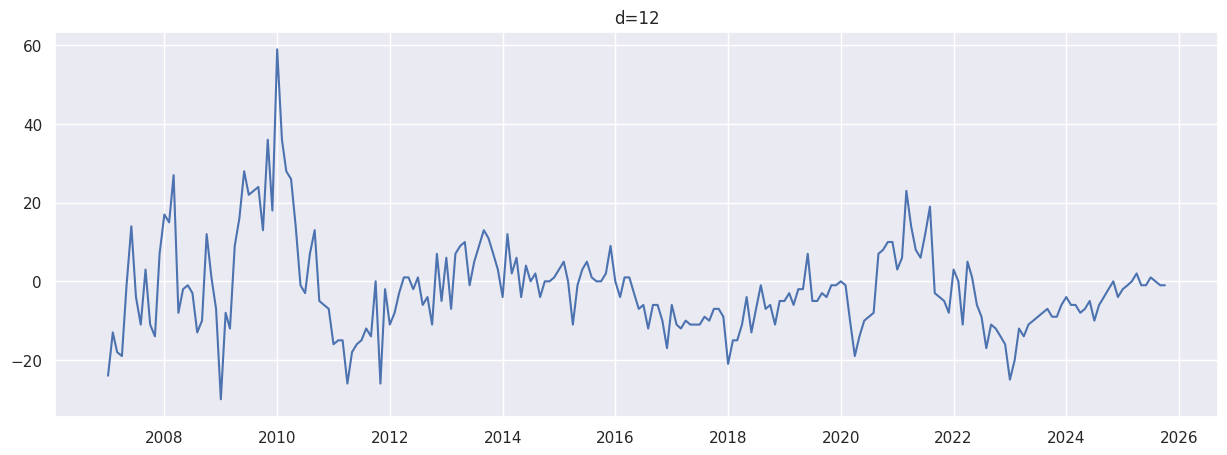

In [ ]:
#Graficamos d=12

plt.figure(figsize=(15,5))
plt.title("d=12")
plt.plot(data["d12_Busquedas"])
plt.show()

In [ ]:
# Verificamos si nuestros datos ahora son estacionarios.

adfuller_test(data["d12_Busquedas"].dropna()) # Eliminamos los valores nulos.

ADF Test Statistic : -2.929878564952513
p-value : 0.04198221968773496
#Lags Used : 14
Number of Observations Used : 211
El valor de p es menor a 0.05, lo que significa que podemos rechazar la hipótesis nula H0. Podemos concluir que los datos no tienen raíz unitaria y son estacionarios.


Al analizar la serie con una diferencia estacional de 12 meses, se observa que, aunque el patrón repetitivo anual se ha mitigado, la serie sigue mostrando una clara tendencia no estacionaria. La media no es constante; se puede ver una deriva descendente a lo largo de los años, especialmente visible después de 2010. Si bien el test ADF arroja un p-valor de 0.042 (técnicamente por debajo de 0.05), es un resultado marginal que sugiere una evidencia de estacionariedad muy débil, mucho menos convincente que el p-valor de 0.0009 obtenido con la diferencia regular.

### Correlograma

In [ ]:
import statsmodels as sm
from statsmodels.graphics import tsaplots

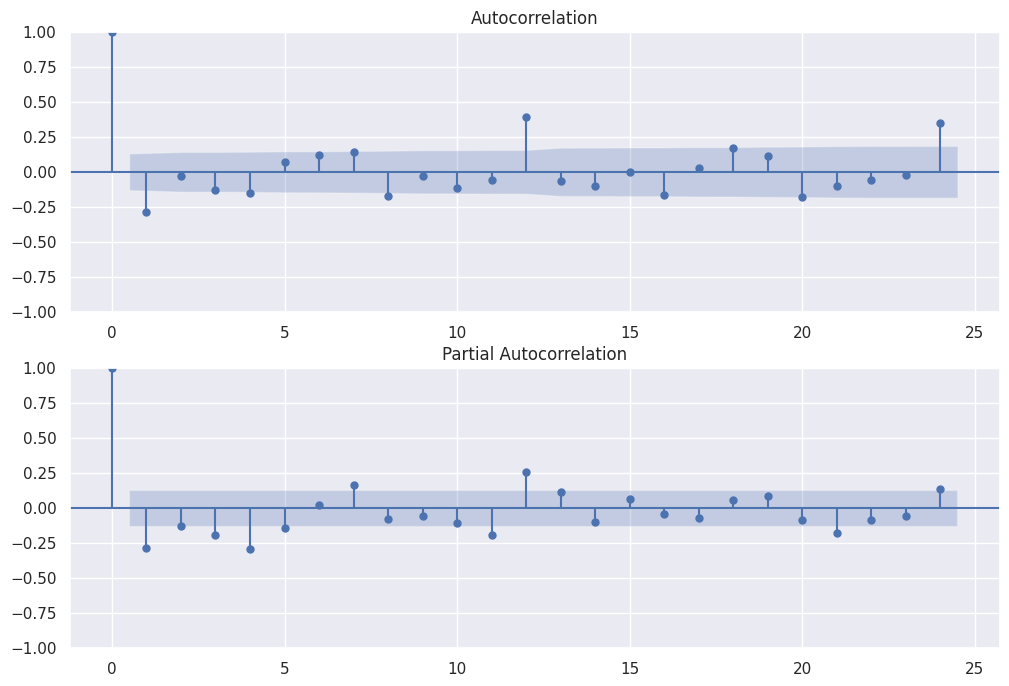

In [ ]:
#Graficamos autocorrelación y autocorrelación parcial

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = tsaplots.plot_acf(data["d1_Busquedas"].iloc[13:],lags=24,ax=ax1) # 2 años de lags
ax2 = fig.add_subplot(212)
fig = tsaplots.plot_pacf(data["d1_Busquedas"].iloc[13:],lags=24,ax=ax2)

En el ACF, se observan picos muy significativos y positivos en los rezagos 12 y 24. Esto indica que el valor de la serie en un mes determinado está fuertemente correlacionado con el valor de hace 12 y 24 meses. Tanto el ACF como el PACF muestran un pico significativo en el rezago 1 que se corta inmediatamente, lo que sugiere un modelo como AR(1) / MA(1). Para la parte estacional, el pico fuerte en el ACF se da en el rezago 12 (anual).

##4.Modelado y predicción

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
import statsmodels as sm

Entrenamos el modelo SARIMA. Se aplica una diferencia regular (d=1) para corregir la tendencia. Además, se incluyen componentes autorregresivos (AR) y de media móvil (MA) tanto para la parte no estacional como para la estacional, y finalmente, con .fit() se ajusta el modelo a los datos.



In [ ]:
model=sm.tsa.statespace.sarimax.SARIMAX(data["Busquedas"],order=(1, 1, 1),seasonal_order=(1,1,1,12)) # 12 periodos de estacionalidad (12 meses)
results=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


###Resultados

In [ ]:
#Visualizamos el resumen de los resultados del modelo

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          Busquedas   No. Observations:                  238
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -746.753
Date:                            Thu, 16 Oct 2025   AIC                           1503.505
Time:                                    00:45:19   BIC                           1520.586
Sample:                                01-01-2006   HQIC                          1510.399
                                     - 10-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1362      0.118      1.158      0.247      -0.094       0.367
ma.L1         -0.6120      0.094     -6.492      0.000      -0.797      -0.427
ar.S.L12      -0.0133      0.091     -0.146      0.884      -0.192       0.166
ma.S.L12      -0.8097      0.093     -8.703      0.000      -0.992      -0.627
sigma2        42.1203      3.224     13.063      0.000      35.801      48.440
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                49.01
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               0.23   Skew:                             0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

En conjunto, el modelo captura bien la estacionalidad y los errores pasados, pero podría mejorarse ajustando la estructura o transformando los datos para mejorar la normalidad de los residuos.

###Gráfica forecast vs real

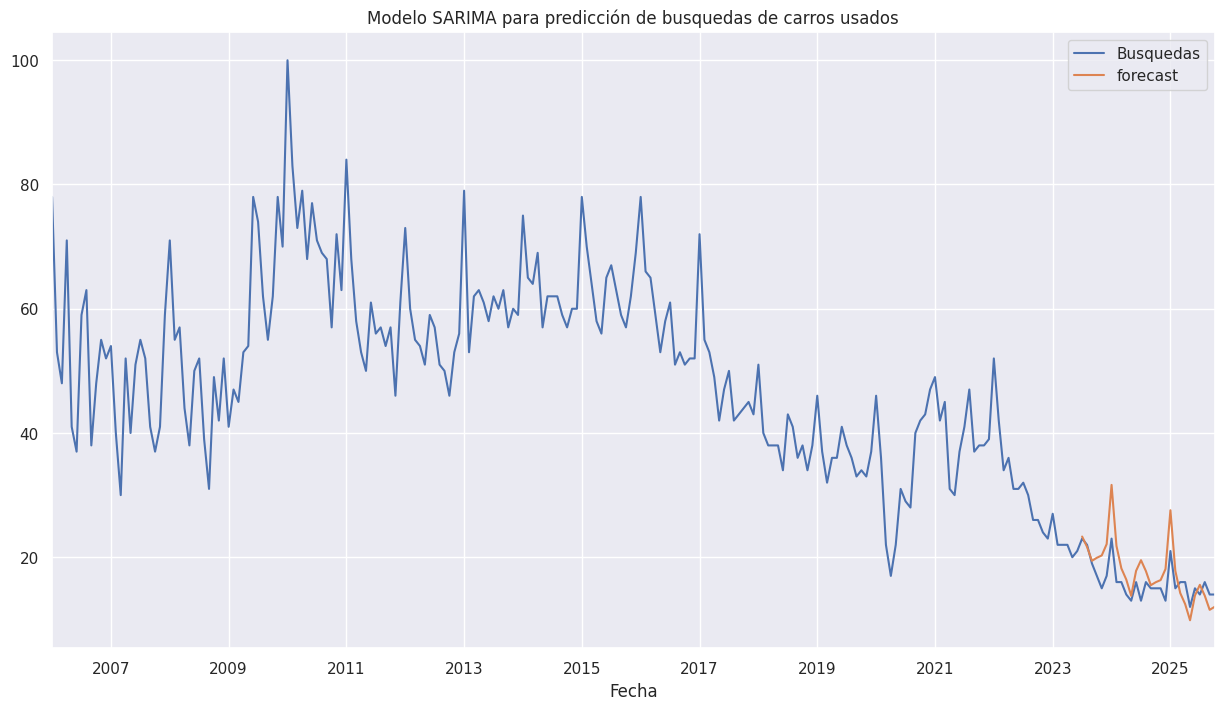

In [ ]:
#Visualizamos la serie original y la predicción (12%)

data['forecast']=results.predict(start=210,end=238,dynamic=True)
data[['Busquedas','forecast']].plot(figsize=(15,8))
plt.title('Modelo SARIMA para predicción de busquedas de carros usados')
plt.show()

El modelo visualmente parece capturar bien el patrón histórico. Debido al crecimiento de plataformas especializadas como Marketplace, Mercado Libre, TucarroYa y otras alternativas de búsqueda, es probable que las consultas directas en Google sobre carros usados en Antioquia disminuyan progresivamente.



Investigando más sobre el tema, hemos encontrado que los picos de finales e inicios de año se deben principalmente a mayor oferta y mayor demanda debido a que los vendedores intentan cambiar el modelo de su auto, y los consecionarios hacen promociones por estas fechas; debido a la alta oferta hay mayor poder de negociación y se pueden conseguir mejores precios en estos meses. De marzo a abril el mercado se mueve poco por impuestos, matrícula y vacaciones de Semana Santa. Y de agosto a septiembre hay menos actividad comercial y pocas promociones. Estos hallazgos contrastan muy bien con la serie y sus patrones.

Se utiliza el último 12% de la serie como conjunto de prueba. Esta selección es crítica para asegurar que el modelo no solo memoriza patrones pasados, sino que puede extrapolar la tendencia decreciente más reciente, que es el comportamiento dominante actual. Un buen desempeño aquí aumenta la confianza en las proyecciones futuras.

In [ ]:
from pandas.tseries.offsets import DateOffset

future_dates = [data.index[-1]+ DateOffset(months=x)for x in range(0,36)] # 3 años = 36 meses

In [ ]:
future_datest_df = pd.DataFrame(index=future_dates[1:],columns=data.columns) # Creamos un dataframe con las fechas futuras y las columnas del dataframe original (df)

In [ ]:
print(future_datest_df)

           Busquedas d1_Busquedas d12_Busquedas forecast
2025-11-01       NaN          NaN           NaN      NaN
2025-12-01       NaN          NaN           NaN      NaN
2026-01-01       NaN          NaN           NaN      NaN
2026-02-01       NaN          NaN           NaN      NaN
2026-03-01       NaN          NaN           NaN      NaN
2026-04-01       NaN          NaN           NaN      NaN
2026-05-01       NaN          NaN           NaN      NaN
2026-06-01       NaN          NaN           NaN      NaN
2026-07-01       NaN          NaN           NaN      NaN
2026-08-01       NaN          NaN           NaN      NaN
2026-09-01       NaN          NaN           NaN      NaN
2026-10-01       NaN          NaN           NaN      NaN
2026-11-01       NaN          NaN           NaN      NaN
2026-12-01       NaN          NaN           NaN      NaN
2027-01-01       NaN          NaN           NaN      NaN
2027-02-01       NaN          NaN           NaN      NaN
2027-03-01       NaN          N

In [ ]:
future_df = pd.concat([data,future_datest_df]) # Concatenamos los dos dataframes (df y future_df)

/tmp/ipython-input-2016532144.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df = pd.concat([data,future_datest_df]) # Concatenamos los dos dataframes (df y future_df)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/kalman_filter.py:2473: ValueWarning: Dynamic prediction specified to begin during out-of-sample forecasting period, and so has no effect.
  warn('Dynamic prediction specified to begin during'


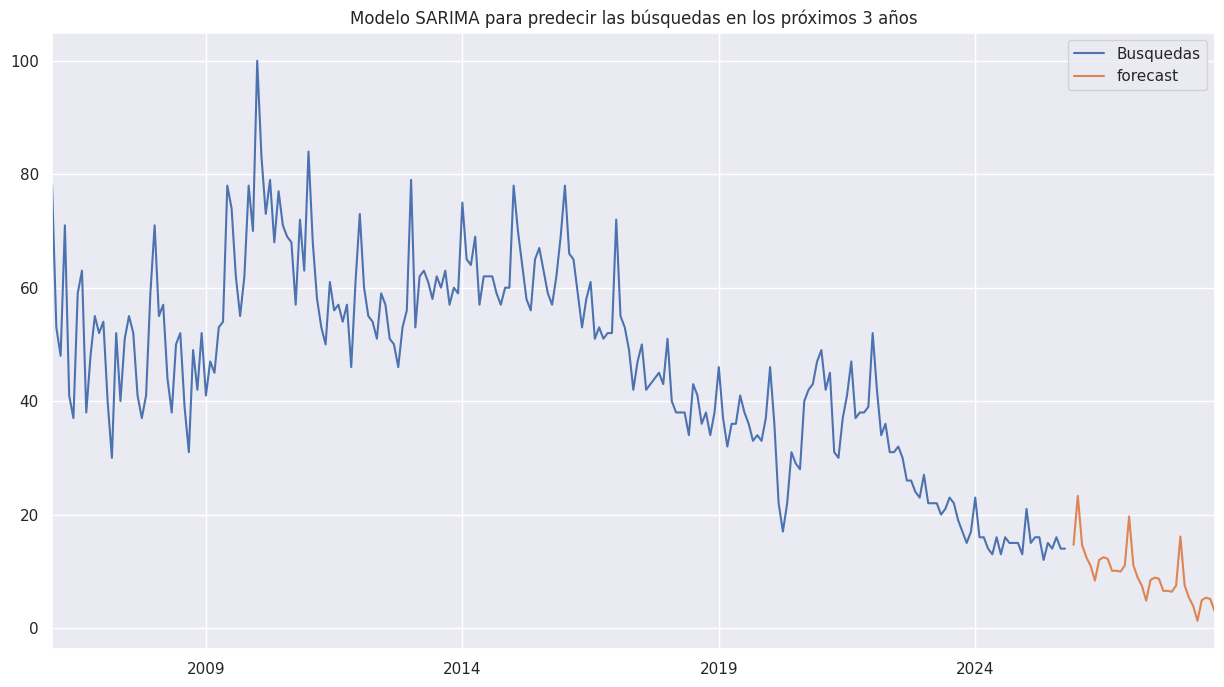

In [ ]:
#Graficamos la predicción para los próximos 3 años

future_df['forecast'] = results.predict(start = 239, end = 273, dynamic= True)
future_df[['Busquedas', 'forecast']].plot(figsize=(15, 8))
plt.title('Modelo SARIMA para predecir las búsquedas en los próximos 3 años')
plt.show()

En el pronóstico de la serie, se logra evidenciar que para los próximos 3 años se estima que las búsquedas sigan disminuyendo, continando la tendencia actual con picos a inicios de cada año.

##5.Evaluación

###RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

actual_values = data['Busquedas'][210:]
predicted_values = data['forecast'][210:]

#Calculamos el RMSE para evaluar el modelo

mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 3.5392390672467484


Representa la raíz cuadrada del promedio de los errores al cuadrado. Penaliza más los errores grandes que el MAE (porque los eleva al cuadrado). También se expresa en las mismas unidades que los datos originales.

Al ser de 3.5, significa que la predicción es cercana a los valores reales.

###MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

#Calculamos el MAE para evaluar el modelo

mae = mean_absolute_error(actual_values, predicted_values)
print(f"MAE: {mae}")

MAE: 2.8024262188208064


Significa que, en promedio, las predicciones del modelo se desvían 2.80 unidades del valor real. Esto indica cuánto se equivoca el modelo, en promedio, sin importar la dirección del error. Cuanto menor sea el MAE, mejor es el desempeño del modelo.

Como el RMSE > MAE, significa que hay algunos errores grandes (outliers o predicciones con desviaciones más fuertes), pero en general el modelo tiene un buen desempeño, ya que los valores son bajos y cercanos entre sí.

###Resultados, mejoras y limitaciones

Resultados:
* La diferenciación regular (d=1) permitió modelar la tendencia decreciente observada en los últimos años. El pronóstico a 3 años extrapola esta tendencia, sugiriendo que el interés de búsqueda directa en Google seguirá disminuyendo, probablemente por la migración de usuarios a plataformas especializadas como fue hipotetizado anteriormente.

* La diferenciación y los componentes estacionales capturaron el patrón anual recurrente, prediciendo correctamente los picos de interés a principios de año (enero) y los valles en los meses de baja actividad comercial.

* El pronóstico del modelo puede ser utilizado por concesionarios, vendedores y otros actores del sector automotriz en Antioquia para anticipar los ciclos de demanda. Por ejemplo, pueden planificar campañas de marketing y gestión de inventario para alinearlas con los picos de interés pronosticados a inicios de cada año.

Limitaciones:
* Como se observó en el análisis exploratorio, la volatilidad de la serie cambia con el tiempo. El modelo SARIMA estándar asume una varianza constante.

* El modelo es univariado, es decir, solo utiliza los valores pasados de la propia serie para predecir el futuro. No puede explicar por qué la tendencia está bajando ni reaccionar a shocks externos imprevistos (como la pandemia de COVID-19) más que tratándolos como grandes errores.

* Un evento como la pandemia representa un quiebre estructural, incluso el cambio de patrones de consumidor donde ya no busca directamente en google sino en otras plataformas, es también un cambio estructural. El modelo SARIMA no está diseñado para manejar estos cambios abruptos en el comportamiento de la serie, lo que puede afectar la precisión de sus parámetros y pronósticos a largo plazo.



Posibles Mejoras:
*  Para abordar la varianza no constante y mejorar la normalidad de los residuos, se podría aplicar una transformación Box-Cox o logarítmica a la serie de datos original antes de ajustar el modelo.

* Una mejora sustancial sería pasar a un modelo SARIMAX. Este permitiría incluir variables externas que influyen en la búsqueda de autos usados. Algunas candidatas podrían ser indicadores económicos de Antioquia, precio de la gasolina, e índice de popularidad de plataformas competidoras como Marketplace, Tucarro, etc.

* Para el impacto de la pandemia en 2020, se podría incluir una variable de intervención (dummy) que tome el valor de 1 durante los meses de confinamiento estricto y 0 en el resto. Esto ayudaría al modelo a aislar el efecto de ese evento anómalo.

* Comparar el rendimiento del SARIMA con otros modelos de series de tiempo como Prophet (es muy robusto con múltiples estacionalidades y eventos) o modelos de Machine Learning como LSTM (Long Short-Term Memory), que pueden capturar patrones no lineales complejos de forma más eficaz.